In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
import duckdb
import logging
import os
from datetime import datetime

In [33]:
# ── LOGGING SETUP ──────────────────────────────────────────────────────────────
# Log to both console and a timestamped file so every run has its own record
os.makedirs("logs", exist_ok=True)
log_filename = f"logs/solution_pipeline_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    handlers=[
        logging.FileHandler(log_filename),
        logging.StreamHandler()
    ]
)
log = logging.getLogger(__name__)
log.info(f"Pipeline started — log: {log_filename}")
 
 
# ── SECTION 1: DATABASE CONNECTION & TABLE LOADING ────────────────────────────
# Connect to persistent DuckDB database and load each parquet file as a table.
# CREATE OR REPLACE TABLE means re-running this cell won't throw a "table exists" error.
log.info("Connecting to DuckDB and loading parquet files...")
 
base = "/Users/aidanmayhue/Desktop/datascience/data_by_design/hw8"
con  = duckdb.connect("assets.db")
 
parquet_tables = {
    "bonds":       f"{base}/data/bond_prices.parquet",
    "crypto":      f"{base}/data/crypto_prices.parquet",
    "etf":         f"{base}/data/etf_prices.parquet",
    "stocks":      f"{base}/data/stock_prices.parquet",
    "all_assets":  f"{base}/data/asset_table.parquet",
    "performance": f"{base}/data/performance_metrics.parquet",
}
 
# Load each parquet file into DuckDB and then into a pandas DataFrame.
# Failures are caught per-table so one bad file doesn't stop the rest.
dataframes = {}
for table_name, path in parquet_tables.items():
    try:
        if not os.path.exists(path):
            raise FileNotFoundError(f"Parquet file not found: {path}")
        con.execute(f"CREATE OR REPLACE TABLE {table_name} AS SELECT * FROM '{path}'")
        dataframes[table_name] = con.execute(f"SELECT * FROM {table_name}").df()
        log.info(f"  Loaded '{table_name}': {len(dataframes[table_name]):,} rows")
    except FileNotFoundError as e:
        log.error(f"  Missing file for '{table_name}': {e}")
    except Exception as e:
        log.error(f"  Failed to load '{table_name}': {e}", exc_info=True)
 
# Unpack into named variables for convenience — fall back to empty DataFrame
# if a table failed to load so downstream code doesn't crash on NameError
bonds       = dataframes.get("bonds",       pd.DataFrame())
crypto      = dataframes.get("crypto",      pd.DataFrame())
etf         = dataframes.get("etf",         pd.DataFrame())
stocks      = dataframes.get("stocks",      pd.DataFrame())
all_assets  = dataframes.get("all_assets",  pd.DataFrame())
performance = dataframes.get("performance", pd.DataFrame())
 
# Fix Arrow-backed string columns that DuckDB returns — convert to standard
# Python strings so groupby, merges, and comparisons behave as expected
for name, df in dataframes.items():
    for col in df.select_dtypes(include="string").columns:
        df[col] = df[col].astype(str)
log.info("Arrow string columns converted to standard dtype")



2026-03-31 18:45:45 [INFO] Pipeline started — log: logs/solution_pipeline_20260331_184545.log
2026-03-31 18:45:45 [INFO] Connecting to DuckDB and loading parquet files...
2026-03-31 18:45:45 [INFO]   Loaded 'bonds': 378,639 rows
2026-03-31 18:45:45 [INFO]   Loaded 'crypto': 177,425 rows
2026-03-31 18:45:46 [INFO]   Loaded 'etf': 954,091 rows
2026-03-31 18:45:47 [INFO]   Loaded 'stocks': 3,486,691 rows
2026-03-31 18:45:47 [INFO]   Loaded 'all_assets': 884 rows
2026-03-31 18:45:47 [INFO]   Loaded 'performance': 3,532 rows
2026-03-31 18:45:47 [INFO] Arrow string columns converted to standard dtype


In [34]:
# ── SECTION 2: HIGH PERFORMERS QUERY ─────────────────────────────────────────
# Filter performance table to assets with >10% annualized return.
# Sorted descending so the best performers appear at the top.
log.info("Querying high-performing assets (AnnualizedReturn > 10%)...")
 
try:
    highperf = con.execute("SELECT * FROM performance WHERE AnnualizedReturn > .10").df()
    highperf = highperf.sort_values(by=["AnnualizedReturn"], ascending=False)
    log.info(f"  High performers found: {len(highperf)}")
except Exception as e:
    log.error(f"  High performer query failed: {e}", exc_info=True)
    highperf = pd.DataFrame()

2026-03-31 18:45:47 [INFO] Querying high-performing assets (AnnualizedReturn > 10%)...
2026-03-31 18:45:47 [INFO]   High performers found: 1357


In [35]:
# ── SECTION 3: COLUMN VALIDATION ─────────────────────────────────────────────
# Quick sanity check — print column names for each price DataFrame.
# Useful for catching schema mismatches between parquet files early.
log.info("Validating columns across price DataFrames...")
 
for name, df in [("etf", etf), ("crypto", crypto), ("bonds", bonds), ("stocks", stocks)]:
    if df.empty:
        log.warning(f"  '{name}' is empty — skipping column check")
        continue
    log.info(f"  {name}: {df.columns.tolist()}")
    log.info(f"  {name} AssetClass values: {df['AssetClass'].unique().tolist()}")
 

2026-03-31 18:45:47 [INFO] Validating columns across price DataFrames...
2026-03-31 18:45:47 [INFO]   etf: ['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume', 'AssetClass', 'Category']
2026-03-31 18:45:47 [INFO]   etf AssetClass values: ['ETF']
2026-03-31 18:45:47 [INFO]   crypto: ['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume', 'AssetClass', 'Category']
2026-03-31 18:45:47 [INFO]   crypto AssetClass values: ['Crypto']
2026-03-31 18:45:47 [INFO]   bonds: ['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume', 'AssetClass', 'Category']
2026-03-31 18:45:47 [INFO]   bonds AssetClass values: ['Bond']
2026-03-31 18:45:47 [INFO]   stocks: ['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume', 'AssetClass', 'Category']
2026-03-31 18:45:47 [INFO]   stocks AssetClass values: ['Stock']


In [36]:
# ── SECTION 4: PRICE DATA PREPARATION ────────────────────────────────────────
# Combine all four asset class price DataFrames into one unified DataFrame.
# Then compute daily capital gain and cumulative gain per ticker.
log.info("Preparing combined price data...")
 
try:
    # Guard against empty DataFrames before concat
    available = {k: v for k, v in {"etf": etf, "crypto": crypto, "bonds": bonds, "stocks": stocks}.items() if not v.empty}
    if not available:
        raise ValueError("All price DataFrames are empty — cannot build all_prices")
 
    all_prices = pd.concat(list(available.values()))
    log.info(f"  Combined rows before cleaning: {len(all_prices):,}")
 
    # Parse Date column to datetime so time-based operations work correctly
    all_prices["Date"] = pd.to_datetime(all_prices["Date"])
    all_prices = all_prices.sort_values(["Ticker", "Date"])
 
    # Daily capital gain = (Close - Open) / Open
    # Measures intraday price movement as a percentage
    all_prices["CapitalGain"] = (all_prices["Close"] - all_prices["Open"]) / all_prices["Open"]
 
    # Remove extreme outliers — daily moves beyond ±50% are likely data errors
    before = len(all_prices)
    all_prices = all_prices[(all_prices["CapitalGain"] >= -0.5) & (all_prices["CapitalGain"] <= 0.5)]
    all_prices = all_prices.replace([np.inf, -np.inf], np.nan).dropna(subset=["CapitalGain"])
    removed = before - len(all_prices)
    log.info(f"  Removed {removed:,} outlier rows ({removed/before*100:.2f}%)")
    log.info(f"  Rows after cleaning: {len(all_prices):,}")
 
    # Cumulative capital gain per ticker — running sum of daily gains
    all_prices["CumulativeGain"] = all_prices.groupby("Ticker")["CapitalGain"].cumsum()
 
    # Average cumulative gain per asset class per date — used for regression
    daily_avg = (
        all_prices
        .groupby(["Date", "AssetClass"])
        .agg(AvgCumulativeGain=("CumulativeGain", "mean"))
        .reset_index()
    )
 
    # DayNumber converts dates to integers for linear regression (sklearn needs numeric X)
    min_date = daily_avg["Date"].min()
    daily_avg["DayNumber"] = (daily_avg["Date"] - min_date).dt.days
 
    log.info(f"  daily_avg shape: {daily_avg.shape}")
    log.info(f"  Crypto max cumulative gain: {daily_avg[daily_avg['AssetClass']=='Crypto']['AvgCumulativeGain'].max():.2f}")
    log.info(f"  Bond max cumulative gain:   {daily_avg[daily_avg['AssetClass']=='Bond']['AvgCumulativeGain'].max():.2f}")
 
    print(daily_avg.head())
 
except Exception as e:
    log.error(f"Price data preparation failed: {e}", exc_info=True)
    daily_avg = pd.DataFrame()

2026-03-31 18:45:47 [INFO] Preparing combined price data...


2026-03-31 18:45:47 [INFO]   Combined rows before cleaning: 4,996,846
2026-03-31 18:45:48 [INFO]   Removed 2,570 outlier rows (0.05%)
2026-03-31 18:45:48 [INFO]   Rows after cleaning: 4,994,276
2026-03-31 18:45:48 [INFO]   daily_avg shape: (30100, 4)
2026-03-31 18:45:48 [INFO]   Crypto max cumulative gain: 3.74
2026-03-31 18:45:48 [INFO]   Bond max cumulative gain:   0.05


        Date AssetClass  AvgCumulativeGain  DayNumber
0 1990-01-02       Bond            0.00000          0
1 1990-01-02        ETF            0.00000          0
2 1990-01-02      Stock            0.01448          0
3 1990-01-03       Bond            0.00000          1
4 1990-01-03        ETF            0.00000          1


In [37]:
# ── SECTION 5: LINEAR REGRESSION PER ASSET CLASS ─────────────────────────────
# Fit a simple OLS regression of AvgCumulativeGain ~ DayNumber for each
# asset class. This captures the long-run trend and lets us compare
# growth trajectories across asset classes.
log.info("Running linear regressions per asset class...")
 
regression_results = {}
 
try:
    if daily_avg.empty:
        raise ValueError("daily_avg is empty — skipping regression")
 
    asset_classes = daily_avg["AssetClass"].unique()
    log.info(f"  Asset classes found: {list(asset_classes)}")
 
    for asset_class in asset_classes:
        try:
            df    = daily_avg[daily_avg["AssetClass"] == asset_class].copy()
            X     = df["DayNumber"].values.reshape(-1, 1)
            y     = df["AvgCumulativeGain"].values
 
            if len(X) < 2:
                log.warning(f"  Skipping {asset_class} — insufficient data points ({len(X)})")
                continue
 
            model     = LinearRegression().fit(X, y)
            r_squared = model.score(X, y)
 
            regression_results[asset_class] = {
                "model":     model,
                "df":        df,
                "slope":     model.coef_[0],
                "intercept": model.intercept_,
                "r_squared": r_squared,
            }
            log.info(f"  {asset_class}: R²={r_squared:.4f}  Slope={model.coef_[0]:.6f}")
            print(f"{asset_class}: R²={r_squared:.4f}  Slope={model.coef_[0]:.6f}")
 
        except Exception as e:
            log.error(f"  Regression failed for {asset_class}: {e}", exc_info=True)
 
except Exception as e:
    log.error(f"Regression section failed: {e}", exc_info=True)

2026-03-31 18:45:48 [INFO] Running linear regressions per asset class...
2026-03-31 18:45:48 [INFO]   Asset classes found: ['Bond', 'ETF', 'Stock', 'Crypto']
2026-03-31 18:45:48 [INFO]   Bond: R²=0.8137  Slope=-0.000039
2026-03-31 18:45:48 [INFO]   ETF: R²=0.9158  Slope=-0.000049
2026-03-31 18:45:48 [INFO]   Stock: R²=0.9498  Slope=0.000223
2026-03-31 18:45:48 [INFO]   Crypto: R²=0.4452  Slope=0.000636


Bond: R²=0.8137  Slope=-0.000039
ETF: R²=0.9158  Slope=-0.000049
Stock: R²=0.9498  Slope=0.000223
Crypto: R²=0.4452  Slope=0.000636


2026-03-31 18:45:48 [INFO] Generating regression plots...
2026-03-31 18:45:49 [INFO]   Plot saved to data/capital_gains_regression_v2.png


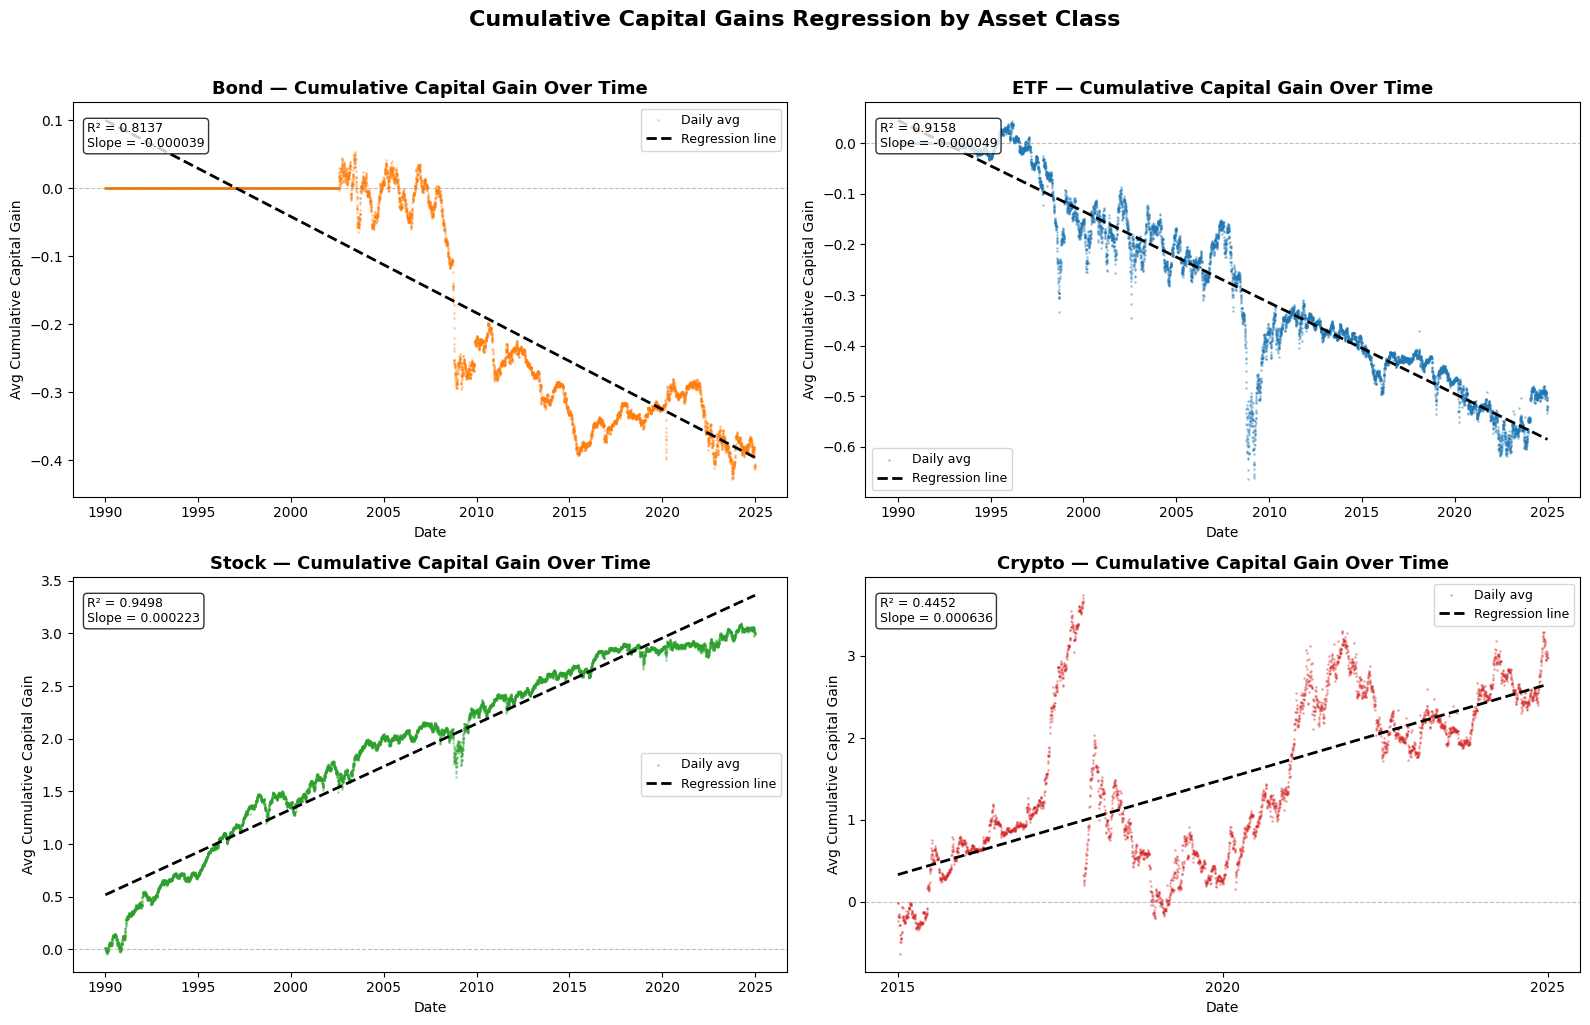

In [38]:
# ── SECTION 6: PLOTTING ───────────────────────────────────────────────────────
# 2x2 subplot grid — one panel per asset class.
# Each panel shows: scatter of daily avg cumulative gain + OLS regression line.
# R² and slope are annotated in the top-left corner of each panel.
log.info("Generating regression plots...")
 
try:
    if not regression_results:
        raise ValueError("No regression results available — skipping plot")
 
    colors = {"ETF": "#1f77b4", "Stock": "#2ca02c", "Bond": "#ff7f0e", "Crypto": "#d62728"}
 
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
 
    for i, (asset_class, results) in enumerate(regression_results.items()):
        try:
            ax    = axes[i]
            df    = results["df"]
            model = results["model"]
            color = colors.get(asset_class, "gray")
 
            # Scatter: each point is one day's average cumulative gain for this asset class
            ax.scatter(df["Date"], df["AvgCumulativeGain"], alpha=0.3, s=1, color=color, label="Daily avg")
 
            # Regression line: predicted values from the fitted OLS model
            y_pred = model.predict(df["DayNumber"].values.reshape(-1, 1))
            ax.plot(df["Date"], y_pred, color="black", linewidth=2, linestyle="--", label="Regression line")
 
            ax.set_title(f"{asset_class} — Cumulative Capital Gain Over Time", fontsize=13, fontweight="bold")
            ax.set_xlabel("Date")
            ax.set_ylabel("Avg Cumulative Capital Gain")
            ax.axhline(y=0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
            ax.xaxis.set_major_locator(mdates.YearLocator(5))
            ax.legend(fontsize=9)
 
            # Annotate R² and slope so model quality is visible without reading logs
            ax.text(0.02, 0.95,
                    f"R² = {results['r_squared']:.4f}\nSlope = {results['slope']:.6f}",
                    transform=ax.transAxes, fontsize=9, verticalalignment="top",
                    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
 
        except Exception as e:
            log.error(f"  Plot panel failed for {asset_class}: {e}", exc_info=True)
 
    plt.suptitle("Cumulative Capital Gains Regression by Asset Class", fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
 
    os.makedirs("data", exist_ok=True)
    output_path = "data/capital_gains_regression_v2.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    log.info(f"  Plot saved to {output_path}")
    plt.show()
 
except Exception as e:
    log.error(f"Plotting failed: {e}", exc_info=True)
 
 


#Visualization Rationale

Due to the differences in scaling across asset types, I decided to create a different plot for each asset. Since I opted to use a linear regression modelI also included a regression line showing the average trend across asset types along with the slope and R^2. Additionally, due to cryptocurrencies being a recent phenomenon the timeline is much shorter compared to the other asset classes, which all start at 1990. I opted to use cumulative capital gain as the feature to visualize due to the general implications of a long term portfolio utilizing a buy and hold strategy. A long term portfolio is only interested in total capital gain, as it is constantly accruing capital due to avoiding an emotional sell off. Since the user is ideally holding to retirement, total capital gain is the only feature relevant for the average buy and hold investor.

In [39]:
# ── SECTION 7: TOP PERFORMING ASSETS ─────────────────────────────────────────
# Rank all assets by 5Y annualized return and show the top 20.
# Merges with all_assets to include AssetClass and Category context.
# Also breaks down top 5 per asset class for easy comparison.
log.info("Building top performers tables...")
 
try:
    if performance.empty:
        raise ValueError("performance DataFrame is empty")
    if all_assets.empty:
        log.warning("all_assets are empty,top assets table will lack AssetClass/Category columns")
 
    # ── Top 20 overall ────────────────────────────────────────────────────────
    top_assets = (
        performance[performance["Period"] == "10Y"]
        .merge(all_assets[["Ticker", "AssetClass", "Category"]], on="Ticker", how="left")
        .sort_values("AnnualizedReturn", ascending=False)
        .head(20)
        [["Ticker", "AssetClass", "Category", "AnnualizedReturn", "TotalReturn", "SharpeRatio", "MaxDrawdown", "Volatility"]]
        .reset_index(drop=True)
    )
 
    top_assets.index += 1  # rank from 1 instead of 0
    top_assets["AnnualizedReturn"] = (top_assets["AnnualizedReturn"] * 100).round(2).astype(str) + "%"
    top_assets["TotalReturn"]      = (top_assets["TotalReturn"]      * 100).round(2).astype(str) + "%"
    top_assets["MaxDrawdown"]      = (top_assets["MaxDrawdown"]      * 100).round(2).astype(str) + "%"
    top_assets["Volatility"]       = (top_assets["Volatility"]       * 100).round(2).astype(str) + "%"
    top_assets["SharpeRatio"]      = top_assets["SharpeRatio"].round(3)
 
    print("=" * 60)
    print("       TOP 20 PERFORMING ASSETS (5Y Annualized Return)")
    print("=" * 60)
    print(top_assets.to_string())
    log.info(f"  Top 20 table built ({len(top_assets)} rows)")
 
    # ── Top 5 per asset class ─────────────────────────────────────────────────
    for asset_class in ["Stock", "ETF", "Crypto", "Bond"]:
        try:
            top = (
                performance[
                    (performance["Period"] == "10Y") &
                    (performance["Ticker"].isin(all_assets[all_assets["AssetClass"] == asset_class]["Ticker"]))
                ]
                .sort_values("AnnualizedReturn", ascending=False)
                .head(5)
                [["Ticker", "AnnualizedReturn", "SharpeRatio", "MaxDrawdown"]]
                .reset_index(drop=True)
            )
            top.index += 1
            print(f"\n── Top 5 {asset_class}s (5Y) ──")
            print(top.to_string())
            log.info(f"  Top 5 {asset_class} table built")
        except Exception as e:
            log.error(f"  Top 5 table failed for {asset_class}: {e}", exc_info=True)
 
except Exception as e:
    log.error(f"Top performers section failed: {e}", exc_info=True)

2026-03-31 18:45:49 [INFO] Building top performers tables...
2026-03-31 18:45:49 [INFO]   Top 20 table built (20 rows)
2026-03-31 18:45:49 [INFO]   Top 5 Stock table built
2026-03-31 18:45:49 [INFO]   Top 5 ETF table built
2026-03-31 18:45:49 [INFO]   Top 5 Crypto table built
2026-03-31 18:45:49 [INFO]   Top 5 Bond table built


       TOP 20 PERFORMING ASSETS (5Y Annualized Return)
       Ticker AssetClass                Category AnnualizedReturn TotalReturn  SharpeRatio MaxDrawdown Volatility
1      OP-USD     Crypto                  Layer2          113.88%  200198.91%        0.001      75.08%  99273.88%
2        NVDA      Stock  Information Technology           75.58%   27748.66%        1.474      66.34%     48.56%
3     SOL-USD     Crypto                  Layer1           69.94%   19985.93%        0.614      96.27%    107.47%
4   MATIC-USD     Crypto                  Layer2           59.13%   10309.14%        0.466      89.86%    118.19%
5     BNB-USD     Crypto                Exchange           55.93%     8395.1%        0.683      75.82%     76.03%
6    DOGE-USD     Crypto                    Meme           53.34%    7089.04%        0.324      92.26%    152.52%
7    LINK-USD     Crypto             Oracle_Data            47.4%    4740.35%        0.449      90.19%      96.7%
8         AMD      Stock  Informa

#Analysis 

For the analysis I wanted to ensure clear outcomes were as comprehensive as possible. The performance_metrics table that I created in the previous section returns both annualized return and total return for each asset. In order to get the top performing portfolio all I needed to do was sort the top performing assets. Additionally, I sorted the top performing assets within each asset class, since based on the visualization, etfs performed poorly in this analysis. Something worth noting is that some assets are performing very well but are additionally far more volatile than something the average long term trader would prefer. These were left in because volatility is rarely relevant in a buy and hold strategy since those kinds of portfoliios are highly diverse. Since individual assets' performance can vary wildly within its class, R^2 and slope were calculated to give users a general understanding of the performance of the asset class.